# 02 — Exploring the self-supervised clusters

This notebook explores the clustering produced by the **first full-scale run**
(`runs/default/`: 88 equivalence-class reps × 256 ICs, 127px, 100 epochs, BYOL +
anti-cheat encoder, with flip+invert symmetry augmentations ON).

**Question for this notebook:** forget for a moment the genotype/phenotype debate —
does the SSL clustering *visually make sense*? We deliberately do **not** treat
"rules are implicitly recovered" as a failure here; we treat it as something to look
at and ask whether the recovered structure is behaviourally sensible.

What we do:
1. load the frozen embeddings + reproduce the exact `evaluate.py` clusters;
2. map the embedding space (UMAP) coloured by discovered cluster, Wolfram class, rule;
3. show **example diagrams** for a curated set of clusters (within-cluster homogeneity,
   between-cluster diversity);
4. coarsen the ~95 fine clusters into a handful of **behaviour super-groups** and check
   whether *those* line up with the classical Wolfram classes.

> **Caveat on labels.** `rule_labels.csv` here is a *best-effort* literature table I
> generated (Wolfram class for all 88 reps; Li–Packard class only for canonical rules,
> blank elsewhere). Please sanity-check / complete it from the authoritative
> Li–Packard table — the colouring is only as good as that file.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from caspectra.config import ExperimentConfig
from caspectra.factory import build_dataset
from caspectra.eval.cluster import cluster_pipeline, umap_project
from caspectra.eval.labels import load_rule_labels

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RUN = ROOT / "runs" / "default"
EVAL = RUN / "eval"

cfg = ExperimentConfig.from_yaml(str(ROOT / "configs" / "default.yaml"))
print("run dir:", RUN)
print("eval cluster params: umap_components=%d metric=%s min_cluster_size=%d min_samples=%d seed=%d"
      % (cfg.eval.umap_components, cfg.eval.umap_metric,
         cfg.eval.hdbscan_min_cluster_size, cfg.eval.hdbscan_min_samples, cfg.seed))

run dir: /Users/michielrollier/Documents/GitHub/ssl-ecas/runs/default
eval cluster params: umap_components=10 metric=cosine min_cluster_size=15 min_samples=5 seed=0


## 1. Load embeddings + diagrams, reproduce the clusters

`evaluate.py` saved the frozen embeddings (in dataset order). We rebuild the *same*
dataset (cache hit) so `images[i]` is the diagram behind `embeddings[i]`, then re-run the
identical UMAP→HDBSCAN pipeline to recover the exact cluster labels.

In [2]:
data = np.load(EVAL / "embeddings.npz")
embeddings = data["embeddings"]
rules = data["rules"]            # individual rule per diagram
reps  = data["equiv_reps"]       # equivalence-class representative (orbit) per diagram

# Rebuild the raw-image dataset (no augmentation) — same order as the embeddings.
dataset = build_dataset(cfg.data, training=False)
images = np.asarray(dataset.images)   # (N, H, W) uint8, aligned to embeddings

assert images.shape[0] == embeddings.shape[0]
assert np.array_equal(dataset.rule_ids, rules), "dataset order must match embeddings order"
print(f"{embeddings.shape[0]} diagrams, embedding dim {embeddings.shape[1]}, "
      f"{len(np.unique(reps))} rules")

22528 diagrams, embedding dim 64, 88 rules


In [3]:
# Reproduce evaluate.py's clusters exactly (same params + seed).
report = cluster_pipeline(
    embeddings,
    umap_components=cfg.eval.umap_components,
    umap_metric=cfg.eval.umap_metric,
    min_cluster_size=cfg.eval.hdbscan_min_cluster_size,
    min_samples=cfg.eval.hdbscan_min_samples,
    seed=cfg.seed,
    rules=reps,
)
clab = report.umap_labels                       # HDBSCAN label per diagram (-1 = noise)
clusters = np.array(sorted(c for c in set(clab.tolist()) if c != -1))
print(f"discovered clusters: {len(clusters)} (noise: {int((clab==-1).sum())})")

# 2-D UMAP purely for plotting.
coords2d = umap_project(embeddings, n_components=2, metric=cfg.eval.umap_metric, seed=cfg.seed)
print("2-D projection:", coords2d.shape)

discovered clusters: 95 (noise: 411)


2-D projection: (22528, 2)


## 2. What is a cluster, statistically?

Before pictures: how pure is each cluster with respect to the *rule*, and how many
clusters does a rule get spread over? This quantifies the "rules are implicitly
recovered" observation.

In [4]:
import collections
purity, n_distinct = [], []
owner = collections.defaultdict(set)
for c in clusters:
    m = clab == c
    rs, cnts = np.unique(reps[m], return_counts=True)
    purity.append(cnts.max() / cnts.sum())
    n_distinct.append(len(rs))
    owner[int(rs[cnts.argmax()])].add(int(c))
purity = np.array(purity); n_distinct = np.array(n_distinct)
splits = np.array([len(v) for v in owner.values()])

print(f"cluster->rule purity:  mean={purity.mean():.3f}  median={np.median(purity):.3f}  "
      f"frac>0.9={(purity>0.9).mean():.2f}")
print(f"distinct rules / cluster: mean={n_distinct.mean():.2f}  frac==1rule={(n_distinct==1).mean():.2f}")
print(f"rules owning >=1 cluster: {len(owner)}/88   clusters per rule: mean={splits.mean():.2f} max={splits.max()}")
print()
print("Reading: clusters are near-pure in rule (one cluster ~ one rule), and a few")
print("rules fragment into several clusters. The interesting question is whether these")
print("fine clusters are *arranged* by behaviour -> next sections.")

cluster->rule purity:  mean=0.833  median=0.996  frac>0.9=0.65
distinct rules / cluster: mean=2.12  frac==1rule=0.49
rules owning >=1 cluster: 63/88   clusters per rule: mean=1.51 max=6

Reading: clusters are near-pure in rule (one cluster ~ one rule), and a few
rules fragment into several clusters. The interesting question is whether these
fine clusters are *arranged* by behaviour -> next sections.


## 3. The map: UMAP coloured by cluster, Wolfram class, and rule

If the embedding is behaviourally sensible, points of the same **Wolfram class**
(uniform / periodic / chaotic / complex) should occupy coherent regions, even though the
*fine* clusters split finer than that.

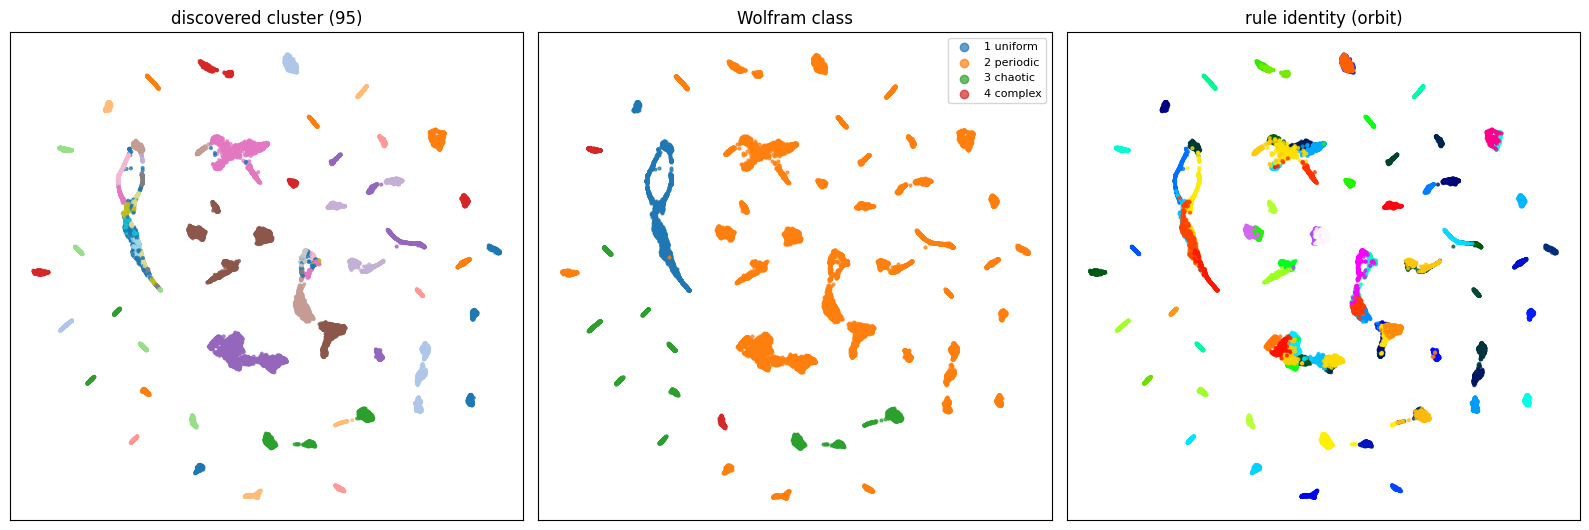

In [5]:
labels = load_rule_labels(str(ROOT / "rule_labels.csv"))
wolf = labels.wolfram_array(reps) if labels else np.full(len(reps), -1)
WNAME = {1: "1 uniform", 2: "2 periodic", 3: "3 chaotic", 4: "4 complex", -1: "unlabelled"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
axes[0].scatter(coords2d[:,0], coords2d[:,1], c=clab, cmap="tab20", s=4, alpha=.7)
axes[0].set_title(f"discovered cluster ({len(clusters)})")

for w in sorted(set(wolf.tolist())):
    m = wolf == w
    axes[1].scatter(coords2d[m,0], coords2d[m,1], s=4, alpha=.7, label=WNAME.get(w, str(w)))
axes[1].set_title("Wolfram class"); axes[1].legend(markerscale=3, fontsize=8, loc="best")

sc = axes[2].scatter(coords2d[:,0], coords2d[:,1], c=reps, cmap="gist_ncar", s=4, alpha=.7)
axes[2].set_title("rule identity (orbit)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

Read the middle panel: do the chaotic (class 3) diagrams clump together and away from
the periodic (class 2) and uniform (class 1) ones? That coarse separation — not the fine
cluster count — is what "the clustering makes sense" means at this stage.

## 4. Example diagrams for a curated set of clusters

We pick ~14 clusters spread across the UMAP map (farthest-point sampling on cluster
centroids) and show the most-central diagrams of each. Within a row the diagrams should
look alike; across rows they should look different.

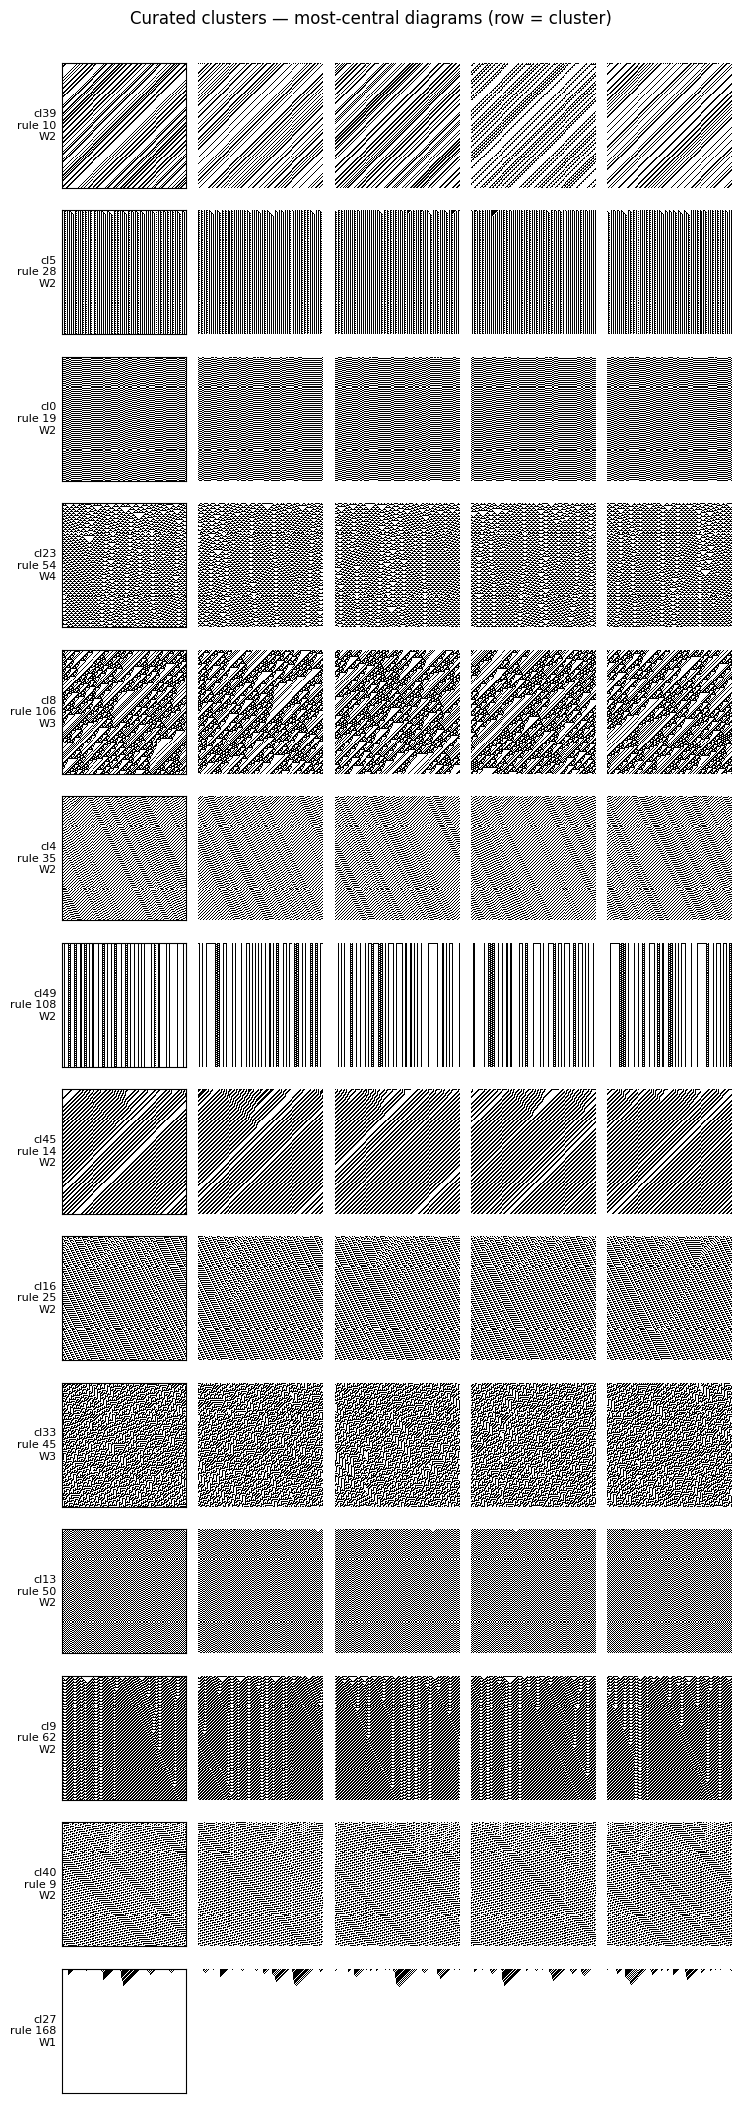

In [6]:
def central_idx(c, k):
    m = np.where(clab == c)[0]
    cen = embeddings[m].mean(0)
    d = np.linalg.norm(embeddings[m] - cen, axis=1)
    return m[np.argsort(d)[:k]]

# Farthest-point sample clusters to span the 2-D map.
cen2d = np.array([coords2d[clab == c].mean(0) for c in clusters])
K = min(14, len(clusters))
sel = [int(np.argmax([(clab == c).sum() for c in clusters]))]   # start from the largest cluster
while len(sel) < K:
    dmin = np.min([np.linalg.norm(cen2d - cen2d[s], axis=1) for s in sel], axis=0)
    for s in sel: dmin[s] = -1
    sel.append(int(np.argmax(dmin)))
sel_clusters = clusters[sel]

NEX = 5
fig, axes = plt.subplots(K, NEX, figsize=(NEX*1.5, K*1.5))
for row, c in enumerate(sel_clusters):
    idx = central_idx(c, NEX)
    rmaj = np.bincount(reps[clab==c]).argmax()
    w = labels.wolfram.get(int(rmaj), -1) if labels else -1
    for col in range(NEX):
        ax = axes[row, col]; ax.axis("off")
        if col < len(idx):
            ax.imshow(images[idx[col]], cmap="binary", interpolation="nearest")
    axes[row,0].set_ylabel(f"cl{c}\nrule {rmaj}\nW{w}", rotation=0, ha="right",
                           va="center", fontsize=8); axes[row,0].axis("on")
    axes[row,0].set_xticks([]); axes[row,0].set_yticks([])
fig.suptitle("Curated clusters — most-central diagrams (row = cluster)", y=1.001)
fig.tight_layout(); plt.show()

## 5. Coarse behaviour super-groups

The ~95 fine clusters are roughly one-per-rule. To ask *"is there behaviour-level
structure?"* we coarsen: cluster the fine-cluster **centroids** (in embedding space) into a
handful of super-groups, then (a) recolour the map by super-group and (b) show example
diagrams + the Wolfram-class makeup of each super-group. If super-groups ≈ Wolfram classes,
the SSL taxonomy is behaviourally sensible at the coarse scale.

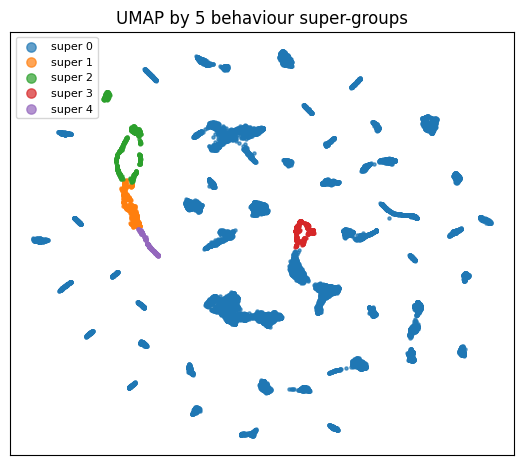

In [7]:
from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering

N_SUPER = 5
cen_emb = normalize(np.array([embeddings[clab == c].mean(0) for c in clusters]))
super_of_cluster = AgglomerativeClustering(n_clusters=N_SUPER).fit_predict(cen_emb)
c2s = {int(c): int(s) for c, s in zip(clusters, super_of_cluster)}
supers = np.array([c2s.get(int(c), -1) for c in clab])   # super-group per diagram (-1 noise)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for s in range(N_SUPER):
    m = supers == s
    ax.scatter(coords2d[m,0], coords2d[m,1], s=5, alpha=.7, label=f"super {s}")
ax.set_title(f"UMAP by {N_SUPER} behaviour super-groups")
ax.set_xticks([]); ax.set_yticks([]); ax.legend(markerscale=3, fontsize=8)
plt.show()

In [8]:
# Wolfram-class composition of each super-group (does it map to a behaviour class?).
print("super-group -> Wolfram-class composition (fraction of diagrams) and top rules")
for s in range(N_SUPER):
    m = supers == s
    if not m.any(): continue
    wv = wolf[m]; ws, wc = np.unique(wv, return_counts=True)
    comp = ", ".join(f"{WNAME.get(int(a),a)}:{b/m.sum():.2f}" for a, b in zip(ws, wc))
    rs, rc = np.unique(reps[m], return_counts=True)
    top = ", ".join(str(int(r)) for r in rs[np.argsort(rc)[::-1][:8]])
    print(f"  super {s} (n={int(m.sum()):5d}): {comp}")
    print(f"            top rules: {top}")

super-group -> Wolfram-class composition (fraction of diagrams) and top rules
  super 0 (n=19989): 2 periodic:0.82, 3 chaotic:0.15, 4 complex:0.03
            top rules: 232, 204, 27, 28, 29, 30, 33, 34
  super 1 (n=  529): 1 uniform:1.00
            top rules: 136, 40, 160, 128, 32, 168
  super 2 (n=  939): 1 uniform:1.00
            top rules: 0, 8, 32, 128, 40, 160, 136
  super 3 (n=  416): 2 periodic:1.00
            top rules: 57, 184, 56
  super 4 (n=  244): 1 uniform:1.00
            top rules: 168, 136, 160, 40


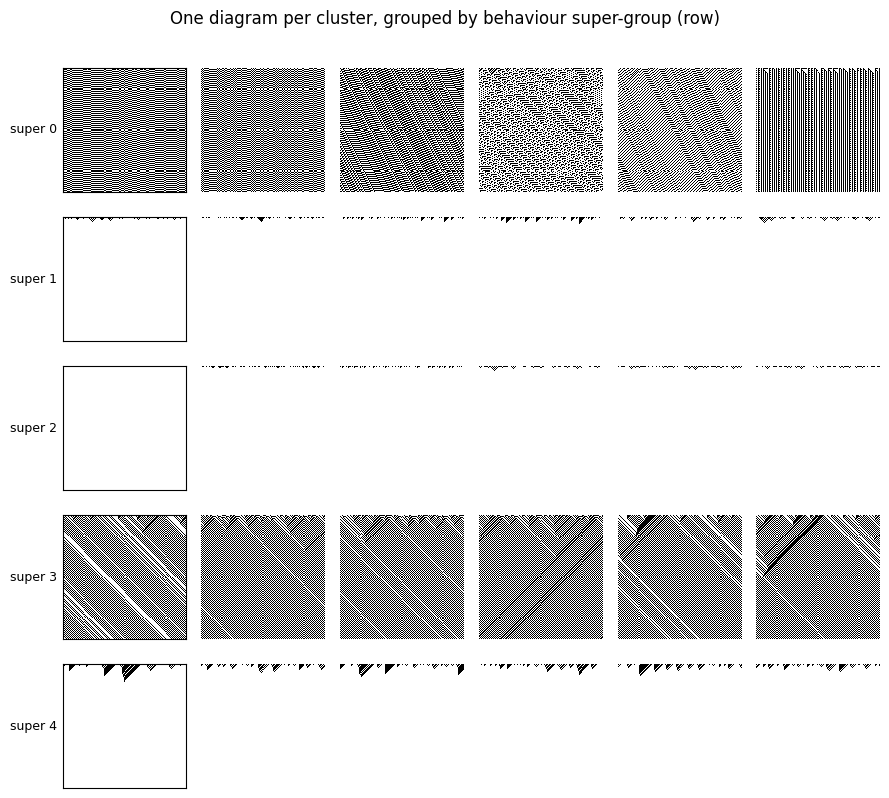

In [9]:
# One example diagram from each of a few clusters per super-group.
fig, axes = plt.subplots(N_SUPER, 6, figsize=(6*1.5, N_SUPER*1.6))
for s in range(N_SUPER):
    cl_in = [c for c in clusters if c2s[int(c)] == s]
    pick = cl_in[:6]
    for col in range(6):
        ax = axes[s, col]; ax.axis("off")
        if col < len(pick):
            idx = central_idx(pick[col], 1)[0]
            ax.imshow(images[idx], cmap="binary", interpolation="nearest")
    axes[s,0].set_ylabel(f"super {s}", rotation=0, ha="right", va="center", fontsize=9)
    axes[s,0].axis("on"); axes[s,0].set_xticks([]); axes[s,0].set_yticks([])
fig.suptitle("One diagram per cluster, grouped by behaviour super-group (row)", y=1.002)
fig.tight_layout(); plt.show()

## 6. Why behaviour did not emerge — where does complexity hide?

The super-groups (§5) separate **homogeneous vs. non-homogeneous**, not order vs. chaos,
and certainly not an isolated *complex / edge-of-chaos* (Wolfram class IV) group. The
sharp question: is the complexity signal **absent** from the embedding, or **present but
not salient**? Two tests:

1. can a *linear* probe separate the complex rules (54, 110) from the chaotic ones?
2. how strongly does the embedding encode the trivial **density / activity** nuisance —
   and is that the dominant geometric (high-variance) axis the clustering follows?

In [10]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, r2_score
from sklearn.preprocessing import StandardScaler
from caspectra.eval.baselines import compute_baseline_features, FEATURE_NAMES

COMPLEX = {54, 110}
CHAOTIC = {18, 22, 30, 45, 60, 90, 105, 106, 122, 126, 146, 150}

# (1) Is class-IV linearly decodable from the embedding?
m = np.isin(reps, list(COMPLEX | CHAOTIC))
y = np.isin(reps[m], list(COMPLEX)).astype(int)
Xtr, Xte, ytr, yte = train_test_split(embeddings[m], y, test_size=.3, random_state=0, stratify=y)
ba = balanced_accuracy_score(yte, LogisticRegression(max_iter=2000).fit(Xtr, ytr).predict(Xte))
print(f"complex(54,110) vs chaotic   linear-probe balanced acc = {ba:.3f}   <- the info IS present")

# (2) How strongly is the density/activity nuisance encoded, and is it the main axis?
feats = compute_baseline_features(images)
dens = feats[:, FEATURE_NAMES.index("mean_density")]
act  = feats[:, FEATURE_NAMES.index("temporal_activity")]
Es = StandardScaler().fit_transform(embeddings)
for nm, t in [("mean_density", dens), ("temporal_activity", act)]:
    a, b, c, e = train_test_split(Es, t, test_size=.3, random_state=0)
    print(f"embedding -> {nm:18s} R^2 = {r2_score(e, Ridge().fit(a, c).predict(b)):.3f}")
U, S, _ = np.linalg.svd(Es - Es.mean(0), full_matrices=False)
ev = (S**2) / (S**2).sum(); pc1 = U[:, 0] * S[0]
print(f"top-1 PC variance = {ev[0]:.2f}  (|corr with density| = {abs(np.corrcoef(pc1, dens)[0,1]):.2f}); "
      f"top-10 PCs = {ev[:10].sum():.2f}")
print()
print("Reading: complexity is ~linearly decodable, but the embedding GEOMETRY is dominated")
print("by density/activity. Unsupervised clustering coarsens along that high-variance axis,")
print("so order/chaos -- a low-variance, subtle coordinate -- is swamped. The signal is")
print("PRESENT but not SALIENT: detectability is not the bottleneck, alignment is.")

complex(54,110) vs chaotic   linear-probe balanced acc = 0.968   <- the info IS present


embedding -> mean_density       R^2 = 0.947
embedding -> temporal_activity  R^2 = 0.955
top-1 PC variance = 0.24  (|corr with density| = 0.61); top-10 PCs = 0.85

Reading: complexity is ~linearly decodable, but the embedding GEOMETRY is dominated
by density/activity. Unsupervised clustering coarsens along that high-variance axis,
so order/chaos -- a low-variance, subtle coordinate -- is swamped. The signal is
PRESENT but not SALIENT: detectability is not the bottleneck, alignment is.


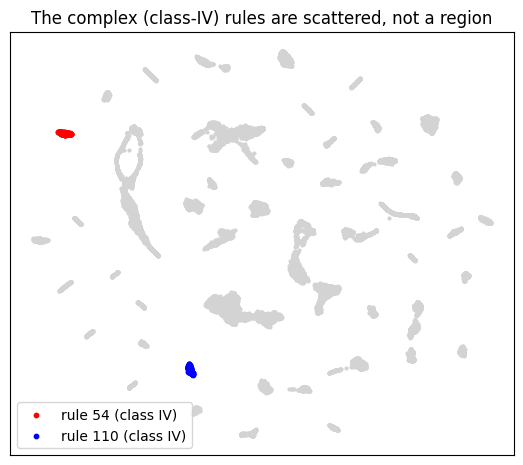

In [11]:
# Where do the class-IV rules actually sit on the map? (Buried, not isolated.)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(coords2d[:,0], coords2d[:,1], s=4, color="lightgray")
for r, col in [(54, "red"), (110, "blue")]:
    mm = reps == r
    ax.scatter(coords2d[mm,0], coords2d[mm,1], s=10, color=col, label=f"rule {r} (class IV)")
ax.set_title("The complex (class-IV) rules are scattered, not a region")
ax.legend(); ax.set_xticks([]); ax.set_yticks([]); plt.show()

## 7. Verdict and the path forward

**What we have.**
- **Fine clusters ≈ rules** (§2): near-pure, ~one cluster per rule. Treated here as an
  interesting *feature* (implicit rule recovery), not the headline failure.
- **Visually coherent clusters** (§4): within-cluster homogeneity, between-cluster
  diversity — the SSL clustering "makes visual sense" at the fine scale.
- **But the only emergent *behavioural* axis is trivial** (§5–§6): the embedding cleanly
  splits **dies-to-uniform vs. everything alive** and nothing finer; complexity is
  linearly decodable (probe ≈ 0.97) yet **not salient** — density/activity is ~95%
  encoded and forms the dominant geometric axis (PC1 ≈ density), so clustering follows it.

**Why (theoretical weaknesses — full version in `SELF_CRITICISM.md`, Level 5).**
- Suppressing the genotype cheat is necessary but **does not point at complexity** — a
  different trivial shortcut (density) fills the vacuum.
- **Complexity is not an invariance to any augmentation**, so nothing in the SSL objective
  biases toward the order/chaos axis.
- A **static 2-D texture model has no notion of computation**; class-IV behaviour is
  dynamical (propagating structures, long transients, long-range correlation).
- The target class is **rare (~2/88) and lacks a per-diagram definition**; density-based
  clustering cannot carve it out, and we have no complexity ground truth to validate.

**How to proceed (to actually *filter out* complex behaviour).**
1. **Cheap first test:** project density/activity out of the embedding and re-cluster — if
   behavioural sub-structure (a class-IV island) appears, the problem was geometry/salience.
2. **Main lever:** inject a **label-free complexity prior** — *damage / difference-pattern
   spreading* is the canonical edge-of-chaos estimator — either as a direct clustering
   feature or as an auxiliary SSL target/metric so "similar" means "similar complexity."
3. **Principled redesign:** a **predictive / world-model** SSL head (forecast future rows
   from past) makes the learned axis track *predictability/computation*, not texture.
4. **Honest scoring:** judge by **per-class recall of class IV vs. a damage-spreading
   baseline**; if the physics baseline wins, that is itself a result about the limits of
   texture SSL for computation-detection.